In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

d:\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\VietUser\.cache\kagglehub\datasets\chiragsaipanuganti\utkface\versions\2


In [4]:
import os
import shutil
import pandas as pd
import random

# CONFIG
SOURCE_PATH = r"C:\Users\VietUser\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1\utkface_aligned_cropped\UTKFace"
OUTPUT_PATH = r"D:\HCSDLDPT\BTL\dataset"

AGE_MIN = 1
AGE_MAX = 10

MAIN_SAMPLES = 600
TEST_SAMPLES = 100

# Soft balance: khong can deu tuyet doi, chi chan mem de tranh tuoi qua nhieu / qua it
MIN_RATIO = 0.7
MAX_RATIO = 1.3

random.seed(42)

# Tạo folder
for folder in ["FullData", "MainData", "Test"]:
    folder_path = os.path.join(OUTPUT_PATH, folder)

    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)

    os.makedirs(folder_path, exist_ok=True)

# Parse dataset
data = []

for file in os.listdir(SOURCE_PATH):
    if not file.lower().endswith(".jpg"):
        continue

    parts = file.split("_")

    if len(parts) < 4:
        continue

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except:
        continue

    if AGE_MIN <= age <= AGE_MAX:
        data.append({
            "filename": file,
            "source_id": file,
            "age": age,
            "gender": gender,
            "race": race,
            "timestamp": "_".join(parts[3:])
        })

df = pd.DataFrame(data)

print("Total filtered:", len(df))

# COPY + SAVE FUNCTION
def copy_and_save(df_subset, folder_name):
    dst_folder = os.path.join(OUTPUT_PATH, folder_name)
    rows = []

    for _, row in df_subset.iterrows():
        src = os.path.join(SOURCE_PATH, row["filename"])
        dst = os.path.join(dst_folder, row["filename"])

        if os.path.exists(src):
            shutil.copy2(src, dst)
            rows.append(row.to_dict())

    df_out = pd.DataFrame(rows).reset_index(drop=True)

    if not df_out.empty:
        df_out.insert(0, "index_id", range(1, len(df_out) + 1))

    df_out.to_csv(os.path.join(dst_folder, "index.csv"), index=False)

    print(f"{folder_name}: {len(df_out)} images")

    return df_out

# SAMPLE SOFT-BALANCE
def distribution_sample(df_subset, target_samples):
    if df_subset.empty:
        return df_subset.copy()

    if len(df_subset) <= target_samples:
        return df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

    ages = sorted(df_subset["age"].unique().tolist())
    age_counts = df_subset["age"].value_counts().sort_index()

    ideal_per_age = target_samples / len(ages)
    min_per_age = max(1, round(ideal_per_age * MIN_RATIO))
    max_per_age = max(min_per_age, round(ideal_per_age * MAX_RATIO))

    quotas = {}
    raw_quotas = {}
    lower_bounds = {}
    upper_bounds = {}

    # Bước 1: quota gốc theo phân bố thật + chặn mềm min/max
    for age in ages:
        available = int(age_counts[age])
        raw_quota = (available / len(df_subset)) * target_samples

        lower_bound = min(available, min_per_age)
        upper_bound = min(available, max_per_age)

        quota = round(raw_quota)
        quota = max(lower_bound, min(quota, upper_bound))

        raw_quotas[age] = raw_quota
        lower_bounds[age] = lower_bound
        upper_bounds[age] = upper_bound
        quotas[age] = quota

    total_selected = sum(quotas.values())

    # Bước 2: nếu dư thì giảm ở nhóm đang vượt quota tự nhiên nhiều nhất
    while total_selected > target_samples:
        candidates = [age for age in ages if quotas[age] > lower_bounds[age]]

        if not candidates:
            candidates = [age for age in ages if quotas[age] > 0]

        if not candidates:
            break

        age_to_reduce = max(
            candidates,
            key=lambda age: (quotas[age] - raw_quotas[age], quotas[age])
        )

        quotas[age_to_reduce] -= 1
        total_selected -= 1

    # Bước 3: nếu thiếu thì tăng ở nhóm đang thấp hơn quota tự nhiên
    while total_selected < target_samples:
        candidates = [age for age in ages if quotas[age] < upper_bounds[age]]

        if not candidates:
            candidates = [age for age in ages if quotas[age] < int(age_counts[age])]

        if not candidates:
            break

        age_to_add = max(
            candidates,
            key=lambda age: (
                raw_quotas[age] - quotas[age],
                int(age_counts[age]) - quotas[age],
                -quotas[age]
            )
        )

        quotas[age_to_add] += 1
        total_selected += 1

    # Bước 4: sample thật theo quota cuối cùng
    selected_parts = []

    for age in ages:
        df_age = df_subset[df_subset["age"] == age]
        n = min(quotas[age], len(df_age))

        if n > 0:
            selected = df_age.sample(n=n, random_state=42)
            selected_parts.append(selected)

    sampled_df = pd.concat(selected_parts)
    sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

    return sampled_df

# 1. FULL DATA
full_df = copy_and_save(df, "FullData")

# 2. MAIN DATA
main_df = distribution_sample(df, MAIN_SAMPLES)
main_df = copy_and_save(main_df, "MainData")

# 3. TEST DATA (không trùng)
remaining_df = df[~df["source_id"].isin(main_df["source_id"])].copy()

test_df = distribution_sample(remaining_df, TEST_SAMPLES)
test_df = copy_and_save(test_df, "Test")

# THỐNG KÊ
print("\nFull age distribution:")
print(full_df["age"].value_counts().sort_index())

print("\nMain age distribution:")
print(main_df["age"].value_counts().sort_index())

print("\nTest age distribution:")
print(test_df["age"].value_counts().sort_index())


Total filtered: 3218
FullData: 3218 images
MainData: 600 images
Test: 100 images

Full age distribution:
age
1     1123
2      482
3      289
4      273
5      196
6      131
7      139
8      263
9      166
10     156
Name: count, dtype: int64

Main age distribution:
age
1     78
2     78
3     72
4     69
5     54
6     42
7     44
8     67
9     49
10    47
Name: count, dtype: int64

Test age distribution:
age
1     13
2     13
3     12
4     12
5      9
6      7
7      7
8     11
9      8
10     8
Name: count, dtype: int64


FullData: Done
MainData: Done
Test: Done


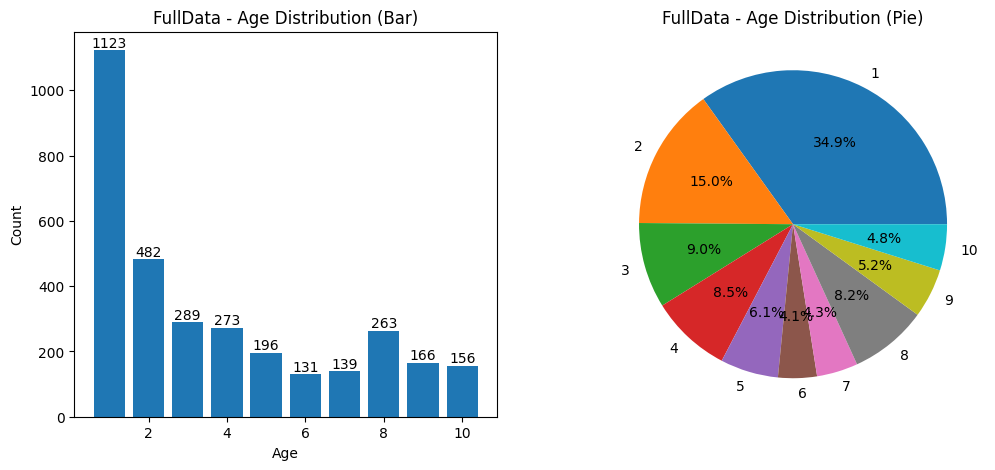

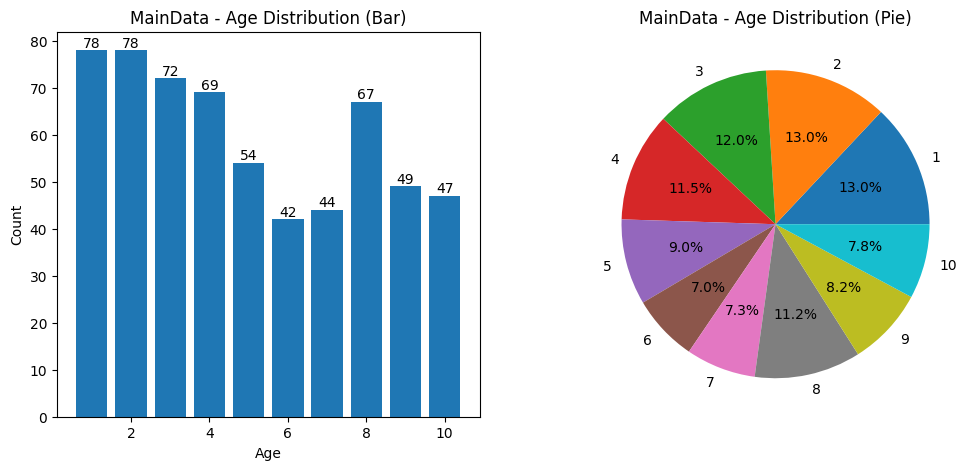

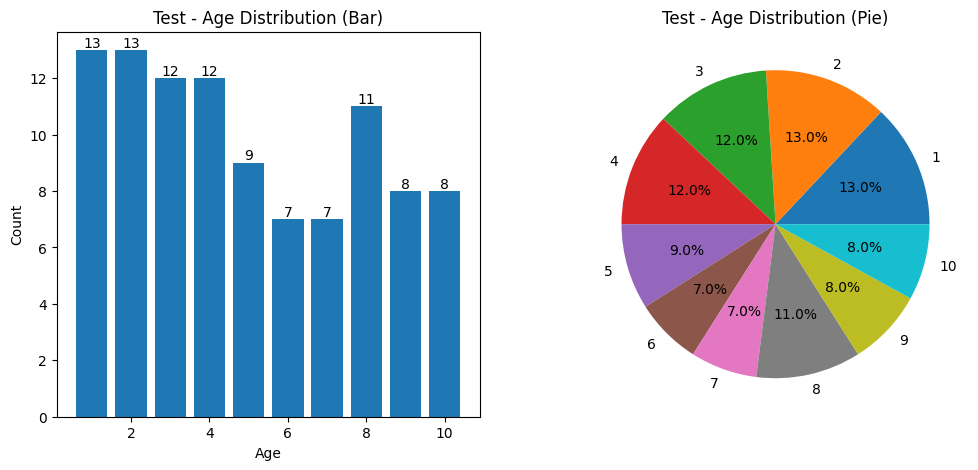

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# CONFIG
BASE_PATH = r"D:\HCSDLDPT\BTL\dataset"
folders = ["FullData", "MainData", "Test"]

for folder in folders:
    path = os.path.join(BASE_PATH, folder, "index.csv")

    if not os.path.exists(path):
        print(f"{folder}: không có index.csv")
        continue

    df = pd.read_csv(path)

    # Đếm số lượng theo tuổi
    age_counts = df["age"].value_counts().sort_index()

    # FIGURE CHUNG
    plt.figure(figsize=(12, 5))

    # BIỂU ĐỒ CỘT
    plt.subplot(1, 2, 1)
    plt.bar(age_counts.index, age_counts.values)
    plt.title(f"{folder} - Age Distribution (Bar)")
    plt.xlabel("Age")
    plt.ylabel("Count")

    # Hiển thị số trên cột (optional nhưng nên có)
    for x, y in zip(age_counts.index, age_counts.values):
        plt.text(x, y, str(y), ha='center', va='bottom')

    # BIỂU ĐỒ TRÒN
    plt.subplot(1, 2, 2)
    plt.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%')
    plt.title(f"{folder} - Age Distribution (Pie)")

    # # ===== Lưu ảnh =====
    # plt.tight_layout()
    # plt.savefig(os.path.join(BASE_PATH, f"{folder}_bar_pie.png"))
    # plt.close()

    print(f"{folder}: Done")